<font color=#85C1E9 size=8>**Predictive Model-Supporting Information**

<font color=#858FE9 size=4>**Integrating Machine Learning and MALDI-TOF Mass Spectrometry for Accurate Detection of Chagas Disease in Clinical Samples**

<font color=#AD85E9 size=3>**Authors: Yenny F. Velandia, Yuly Andrea Pradaa*, Enrique Mejía-Ospinoa**

<font color=#9085E9 size=3>**Universidad Industrial de Santander (Colombia)**

<font color=#858FE1 size=6>**Samples resulting from filtration less than 3kDa**

In [ ]:
!pip install openpyxl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn import preprocessing
from sklearn.metrics import explained_variance_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

<font color=#AD85E9 size=4>**Spectrum reading and Loading of Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

ruta = "/content/drive/MyDrive/all spectra"

print(os.listdir(ruta))

['54S D_0_G23_1.txt', '21A D_0_F19_1.txt', '6S D_0_E4_1.txt', '44N D_0_B10_1.txt', '28A_0_G15_1.txt', '18A D_0_F16_1.txt', '14A D_0_P21_1.txt', '37S D_0_G10_1.txt', '1A D_0_P8_2.txt', '48S D_0_G18_1.txt', '5S D_0_E3_1.txt', '60S_0_H4_1.txt', '35N D_0_P5_1.txt', '23S_0_D19_1.txt', '39N D_0_A9_1.txt', '55S_0_F24_1.txt', '15S_0_D12_1.txt', '31N D_0_B7_1.txt', '18N_0_A6_1.txt', '8S_0_D6_1.txt', '9S_0_D7_1.txt', '5A_0_O11_1.txt', '37N D_0_B8_1.txt', '58S_0_H2_1.txt', '29S_0_F1_1.txt', '12S D_0_E10_1.txt', '3A D_0_P10_1.txt', '28S D_0_E24_1.txt', '14N D_0_B5_1.txt', '26S D_0_E22_1.txt', '32A D_0_H19_1.txt', '31N_0_A7_1.txt', '44N_0_A10_1.txt', '37A_0_G24_1.txt', '50S_0_F20_1.txt', '22S D_0_E18_1.txt', '8N D_0_B3_1.txt', '16S D_0_E13_1.txt', '22S_0_D18_1.txt', '11A_0_O20_1.txt', '21A_0_E19_1.txt', '46S_0_F16_1.txt', '33N_0_O3_1.txt', '59S D_0_I3_1.txt', '15N_0_A8_1.txt', '28N_0_A15_1.txt', '27N D_0_B14_1.txt', '61S D_0_I5_1.txt', '30N_0_O2_1.txt', '18N D_0_B6_1.txt', '51S_0_F21_1.txt', '10N D

In [ ]:
['9A_0_O14_1.txt', '46S_0_F16_1.txt', '17A D_0_F15_1.txt', '13S D_0_E11_1.txt', '1N_0_F2_1.txt', '30N_0_O2_1.txt', '55S D_0_G24_1.txt', '25A_0_E23_1.txt', '56S_0_H1_1.txt', '12N_0_A6_1.txt', '6S_0_D4_1.txt', '22A D_0_F20_1.txt', '63S D_0_I7_1.txt', '14N_0_A5_1.txt', '3N_0_A2_1.txt', '14N D_0_B5_1.txt', '37A_0_G24_1.txt', '33S D_0_G6_1.txt', '5A_0_O11_1.txt', '51S_0_F21_1.txt', '33N D_0_P3_1.txt', '40S_0_F12_1.txt', '30S_0_F4_1.txt', '37S_0_F10_1.txt', '33A D_0_H20_1.txt', '19A_0_E17_1.txt', '46N D_0_P7_1.txt', '23S_0_D19_1.txt', '11A_0_O20_1.txt', '47N_0_A22_1.txt', '16S_0_D13_1.txt', '28N D_0_B15_1.txt', '31N_0_A7_1.txt', '32A D_0_H19_1.txt', '29A_0_G16_1.txt', '35N D_0_P5_1.txt', '26N_0_A13_1.txt', '30A_0_G17_1.txt', '31S_0_F5_1.txt', '54S D_0_G23_1.txt', '21A D_0_F19_1.txt', '6S D_0_E4_1.txt', '44N D_0_B10_1.txt', '28A_0_G15_1.txt', '18A D_0_F16_1.txt', '14A D_0_P21_1.txt', '37S D_0_G10_1.txt', '1A D_0_P8_2.txt', '48S D_0_G18_1.txt', '5S D_0_E3_1.txt', '60S_0_H4_1.txt', '39N D_0_A9_1.txt', '55S_0_F24_1.txt', '15S_0_D12_1.txt', '31N D_0_B7_1.txt', '18N_0_A6_1.txt', '8S_0_D6_1.txt', '9S_0_D7_1.txt', '37N D_0_B8_1.txt', '58S_0_H2_1.txt', '29S_0_F1_1.txt', '12S D_0_E10_1.txt', '3A D_0_P10_1.txt', '28S D_0_E24_1.txt', '26S D_0_E22_1.txt', '44N_0_A10_1.txt', '50S_0_F20_1.txt', '22S D_0_E18_1.txt', '8N D_0_B3_1.txt', '16S D_0_E13_1.txt', '22S_0_D18_1.txt', '21A_0_E19_1.txt', '33N_0_O3_1.txt', '59S D_0_I3_1.txt', '15N_0_A8_1.txt', '28N_0_A15_1.txt', '27N D_0_B14_1.txt', '61S D_0_I5_1.txt', '18N D_0_B6_1.txt', '10N D_0_B4_1.txt', '6A D_0_P12_1.txt', '17A_0_E15_1.txt', '34N D_0_P4_1.txt', '6A_0_O12_1.txt', '27S D_0_E23_1.txt', '45S_0_F15_1.txt', '27A D_0_H14_1.txt', '9A DD_0_P14_1.txt', '24S D_0_E20_1.txt', '16N D_0_B9_1.txt', '47N D_0_B22_1.txt', '25A D_0_F23_1.txt', '51S D_0_G21_1.txt', '30A D_0_H17_1.txt', '10A_0_O19_1.txt', '8A D_0_P13_1.txt', '41S_0_F13_1.txt', '45N_0_A21_1.txt', '23A_0_E21_1.txt', '41N D_0_B19_1.txt', '58S D_0_I2_1.txt', '36S D_0_G9_1.txt', '3S D_0_D5_1.txt', '41N_0_A19_1.txt', '38S_0_F11_1.txt', '32A_0_G19_1.txt', '62S D_0_I6_1.txt', '49S D_0_G19_1.txt', '45N D_0_B21_1.txt', '4S D_0_E2_1.txt', '35N_0_O5_1.txt', '50N_0_A12_1.txt', '19N_0_A11_1.txt', '9S D_0_E7_1.txt', '25N D_0_G3_1.txt', '2A_0_O9_1.txt', '20S D_0_E16_1.txt', '1N D_0_G2_1.txt', '46N_0_O7_1.txt', '49N D_0_B11_1.txt', '7S D_0_E5_1.txt', '44S D_0_G14_1.txt', '9N D_0_B4_1.txt', '34N_0_O4_1.txt', '7S_0_D5_1.txt', '31S D_0_G5_1.txt', '44S_0_F14_1.txt', '26A D_0_F24_1.txt', '28S_0_D24_1.txt', '35S D_0_G8_1.txt', '21S D_0_E17_1.txt', '34S_0_F7_1.txt', '23S D_0_E19_1.txt', '24A_0_E22_1.txt', '30N D_0_P2_1.txt', '33S_0_F6_1.txt', '27A_0_G14_1.txt', '12S_0_D10_1.txt', '11A DD_0_P20_1.txt', '41S D_0_G13_1.txt', '50S D_0_G20_1.txt', '10N_0_A4_1.txt', '28A D_0_H15_1.txt', '3N D_0_B2_1.txt', '20A D_0_F18_1.txt', '20A_0_E18_1.txt', '24S_0_D20_1.txt', '11S_0_D9_1.txt', '47S D_0_G17_1.txt', '8S D_0_E6_1.txt', '3S_0_C5_1.txt', '2A D_0_P9_1.txt', '35A_0_G22_1.txt', '19A D_0_F17_1.txt', '47S_0_F17_1.txt', '63S_0_H7_1.txt', '50N D_0_B12_1.txt', '13S_0_D11_1.txt', '26A_0_E24_1.txt', '19N D_0_B11_1.txt', '52S_0_F22_1.txt', '21N D_0_B12_1.txt', '49S_0_F19_1.txt', '18A_0_E16_1.txt', '48S_0_F18_1.txt', '34A_0_G21_1.txt', '36A D_0_H23_1.txt', '21N_0_A12_1.txt', '4S_0_D2_1.txt', '8N_0_A3_1.txt', '37A D_0_H24_1.txt', '34S D_0_G7_1.txt', '15A_0_E14_1.txt', '25S_0_D21_1.txt', '12N D_0_B6_1.txt', '15N D_0_B8_1.txt', '7N D_0_B2_1.txt', '20S_0_D16_1.txt', '10A D_0_P19_1.txt', '3A_0_O10_1.txt', '15S D_0_E12_1.txt', '36A_0_G23_1.txt', '21S_0_D17_1.txt', '18S D_0_E14_1.txt', '5A D_0_P11_1.txt', '30S D_0_G4_1.txt', '26N D_0_B13_1.txt', '36S_0_F9_1.txt', '38S D_0_G11_1.txt', '45S D_0_G15_1.txt', '39N_0_A9_1.txt', '61S_0_H5_1.txt', '56S D_0_I1_1.txt', '36N D_0_P6_1.txt', '24A D_0_F22_1.txt', '1A _0_O8_1.txt', '31A D_0_H18_1.txt', '39A_0_C4_1.txt', '14A_0_O21_1.txt', '15A D_0_F14_1.txt', '35A D_0_H22_1.txt', '37N_0_A8_1.txt', '29S D_0_G1_1.txt', '39A D_0_D4_1.txt', '18S_0_D14_1.txt', '33A_0_G20_1.txt', '29A D_0_H16_1.txt', '8A_0_O13_1.txt', '40S D_0_G12_1.txt', '16N_0_A9_1.txt', '10S_0_D8_1.txt', '27N_0_A14_1.txt', '11S D_0_E9_1.txt', '26S_0_D22_1.txt', '5S_0_D3_1.txt', '31A_0_G18_1.txt', '62S_0_H6_1.txt', '59S_0_H3_1.txt', '7N_0_A2_1.txt', '27S_0_D23_1.txt', '36N_0_O6_1.txt', '46S D_0_G16_1.txt', '19S D_0_E15_1.txt', '52S D_0_G22_1.txt', '49N_0_A11_1.txt', '34A D_0_H21_1.txt', '10S D_0_E8_1.txt', '54S_0_F23_1.txt', '25S D_0_E21_1.txt', '9N_0_A4_1.txt', '60S D_0_I4_1.txt', '35S_0_F8_1.txt', '23A D_0_F21_1.txt', '19S_0_D15_1.txt', '22A_0_E20_1.txt', '25N_0_F3_1.txt']

['9A_0_O14_1.txt',
 '46S_0_F16_1.txt',
 '17A D_0_F15_1.txt',
 '13S D_0_E11_1.txt',
 '1N_0_F2_1.txt',
 '30N_0_O2_1.txt',
 '55S D_0_G24_1.txt',
 '25A_0_E23_1.txt',
 '56S_0_H1_1.txt',
 '12N_0_A6_1.txt',
 '6S_0_D4_1.txt',
 '22A D_0_F20_1.txt',
 '63S D_0_I7_1.txt',
 '14N_0_A5_1.txt',
 '3N_0_A2_1.txt',
 '14N D_0_B5_1.txt',
 '37A_0_G24_1.txt',
 '33S D_0_G6_1.txt',
 '5A_0_O11_1.txt',
 '51S_0_F21_1.txt',
 '33N D_0_P3_1.txt',
 '40S_0_F12_1.txt',
 '30S_0_F4_1.txt',
 '37S_0_F10_1.txt',
 '33A D_0_H20_1.txt',
 '19A_0_E17_1.txt',
 '46N D_0_P7_1.txt',
 '23S_0_D19_1.txt',
 '11A_0_O20_1.txt',
 '47N_0_A22_1.txt',
 '16S_0_D13_1.txt',
 '28N D_0_B15_1.txt',
 '31N_0_A7_1.txt',
 '32A D_0_H19_1.txt',
 '29A_0_G16_1.txt',
 '35N D_0_P5_1.txt',
 '26N_0_A13_1.txt',
 '30A_0_G17_1.txt',
 '31S_0_F5_1.txt',
 '54S D_0_G23_1.txt',
 '21A D_0_F19_1.txt',
 '6S D_0_E4_1.txt',
 '44N D_0_B10_1.txt',
 '28A_0_G15_1.txt',
 '18A D_0_F16_1.txt',
 '14A D_0_P21_1.txt',
 '37S D_0_G10_1.txt',
 '1A D_0_P8_2.txt',
 '48S D_0_G18_1.txt',
 

In [ ]:
archivos = sorted([f for f in os.listdir(ruta) if f.endswith(".txt")])

print("Número de archivos:", len(archivos))
print(archivos[:5])

Número de archivos: 236
['10A D_0_P19_1.txt', '10A_0_O19_1.txt', '10N D_0_B4_1.txt', '10N_0_A4_1.txt', '10S D_0_E8_1.txt']


In [ ]:
archivo = os.path.join(ruta, archivos[0])

print("Archivo revisado:", archivos[0])

with open(archivo, "r") as f:
    for i in range(15):
        print(f.readline())

Archivo revisado: 10A D_0_P19_1.txt
598.375 267

598.486 381

598.597 588

598.708 735

598.819 803

598.930 624

599.041 405

599.153 171

599.264 71

599.375 94

599.486 162

599.597 320

599.708 537

599.819 627

599.930 578



In [11]:
import glob
fn = []
all_spectra = pd.DataFrame()

In [12]:
import os
import re
import pandas as pd
import numpy as np

# Leer todos los espectros
espectros = []
clases = []
nombres = []

for archivo in archivos:
    path = os.path.join(ruta, archivo)

    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        names=["mz", "intensity"]
    )

    espectros.append(df["intensity"].values)
    nombres.append(archivo)

    # Clase desde el nombre: 10A, 10N, 10S
    clase = re.search(r"^\d+\s*([ANS])", archivo.upper()).group(1)
    clases.append(clase)

# Crear matriz
Dataint = pd.DataFrame(espectros, index=nombres)
Dataint["Clase"] = clases

print("Dataint:", Dataint.shape)
print(Dataint["Clase"].value_counts())
Dataint.head()

Dataint: (236, 23041)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8,9,...,23031,23032,23033,23034,23035,23036,23037,23038,23039,Clase
10A D_0_P19_1.txt,267,381,588,735,803,624,405,171,71,94,...,11,10,4,-3,9,7,15,-1,3,A
10A_0_O19_1.txt,234,415,535,561,432,267,83,-33,27,331,...,9,16,13,7,15,14,4,1,8,A
10N D_0_B4_1.txt,776,896,994,910,814,710,595,629,685,702,...,2,0,4,2,-5,-2,3,-4,-7,N
10N_0_A4_1.txt,823,879,939,882,856,773,725,680,685,882,...,-1,5,5,11,11,14,14,29,36,N
10S D_0_E8_1.txt,872,999,1025,854,548,253,192,350,622,971,...,11,12,-9,3,-6,0,17,2,-2,S


In [13]:
X = Dataint.drop(columns=["Clase"])
y = Dataint["Clase"]

print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

X: (236, 23040)
y: (236,)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


Principal Componts Analysis (PCA) Explorarory!!

In [15]:
X = Dataint.drop(columns=["Clase"])
y = Dataint["Clase"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = le.classes_

print("Classes:", class_names)
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

Classes: ['A' 'N' 'S']
X: (236, 23040)
y: (236,)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


Explained variance: [0.14704836 0.05993323 0.05191248 0.03074688 0.02940873 0.02716257
 0.02259433 0.02109656 0.01834517 0.01444462]
Total variance PC1-PC10: 0.42269292960179455


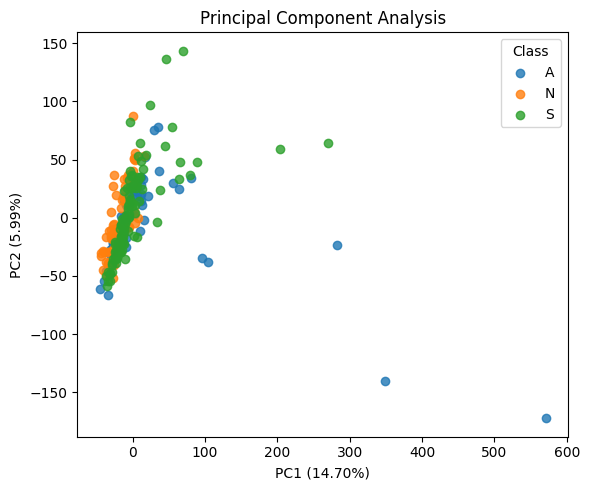

In [16]:
from sklearn.decomposition import PCA

X_scaled_pca = StandardScaler().fit_transform(X)

pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled_pca)

pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(10)])
pca_df["Class"] = y.values

print("Explained variance:", pca.explained_variance_ratio_)
print("Total variance PC1-PC10:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(6, 5))

for class_name in class_names:
    subset = pca_df[pca_df["Class"] == class_name]
    plt.scatter(subset["PC1"], subset["PC2"], label=class_name, alpha=0.8)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("Principal Component Analysis")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig("figures/PCA_PC1_PC2.png", dpi=600)
plt.show()

Linear Discriminant Analysis (LDA)

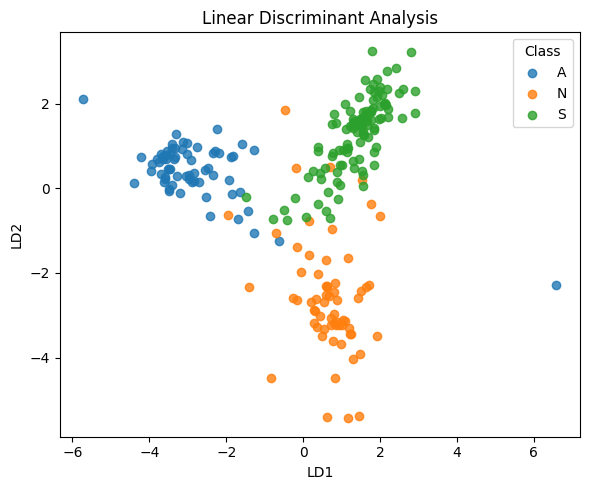

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=2))
])

X_lda = lda_pipe.fit_transform(X, y_encoded)

lda_df = pd.DataFrame(X_lda, columns=["LD1", "LD2"])
lda_df["Class"] = y.values

plt.figure(figsize=(6, 5))

for class_name in class_names:
    subset = lda_df[lda_df["Class"] == class_name]
    plt.scatter(subset["LD1"], subset["LD2"], label=class_name, alpha=0.8)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Linear Discriminant Analysis")
plt.legend(title="Class")
plt.tight_layout()
plt.savefig("figures/LDA.png", dpi=600)
plt.show()

Sample similarity network

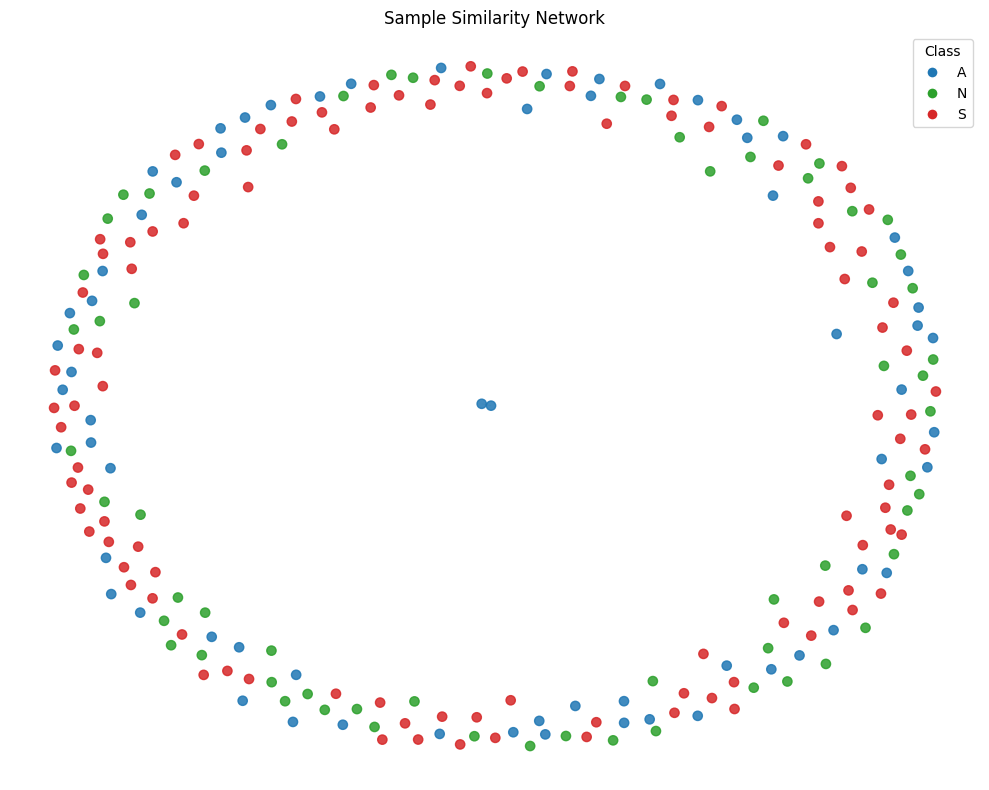

In [18]:
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

X_scaled_net = StandardScaler().fit_transform(X)

similarity = cosine_similarity(X_scaled_net)

threshold = 0.90

G = nx.Graph()

for i, sample in enumerate(X.index):
    G.add_node(sample, label=y.iloc[i])

for i in range(len(X.index)):
    for j in range(i + 1, len(X.index)):
        if similarity[i, j] >= threshold:
            G.add_edge(X.index[i], X.index[j], weight=similarity[i, j])

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=12)

color_map = {
    "A": "#1f77b4",
    "N": "#2ca02c",
    "S": "#d62728"
}

node_colors = [color_map[G.nodes[n]["label"]] for n in G.nodes]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=45, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.5)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=k,
               markerfacecolor=v, markersize=8)
    for k, v in color_map.items()
]

plt.legend(handles=legend_handles, title="Class")
plt.title("Sample Similarity Network")
plt.axis("off")
plt.tight_layout()
plt.savefig("figures/sample_similarity_network.png", dpi=600)
plt.show()

Trainning Models Machine Learning

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=12,
    shuffle=True,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train: (188, 23040)
Test: (48, 23040)
Clase
S    84
A    53
N    51
Name: count, dtype: int64
Clase
S    22
N    13
A    13
Name: count, dtype: int64


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=40, probability=True, random_state=123))
])

svc_pipeline.fit(X_train, y_train)

y_pred = svc_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9583333333333334
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.8667    1.0000    0.9286        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9583        48
   macro avg     0.9556    0.9487    0.9484        48
weighted avg     0.9639    0.9583    0.9581        48

[[11  2  0]
 [ 0 13  0]
 [ 0  0 22]]


In [22]:
X = Dataint.drop(columns=["Clase"])
y = Dataint["Clase"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

class_names = le.classes_

print("Classes:", class_names)
print("X:", X.shape)
print("y:", y.shape)
print(y.value_counts())

Classes: ['A' 'N' 'S']
X: (236, 23040)
y: (236,)
Clase
S    106
A     66
N     64
Name: count, dtype: int64


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    train_size=0.8,
    random_state=12,
    shuffle=True,
    stratify=y_encoded
)

Models defined


In [24]:
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier, LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

models = {
    "Ridge Classifier": RidgeClassifier(),
    "SVC RBF": SVC(kernel="rbf", C=40, probability=True, random_state=123),
    "NuSVC": NuSVC(nu=0.1, kernel="rbf", probability=True, random_state=123),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=123, class_weight="balanced"),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=123),
    "Linear SVC": LinearSVC(C=1.0, max_iter=10000, random_state=123),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=123
    ),
    "SGD Classifier": SGDClassifier(loss="log_loss", max_iter=5000, random_state=123),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=10000, class_weight="balanced", multi_class="auto"),
    "Bagging Classifier": BaggingClassifier(n_estimators=300, random_state=123),
    "ExtraTrees Classifier": ExtraTreesClassifier(n_estimators=300, random_state=123, class_weight="balanced")
}

Metrics and confusion matrix


Ridge Classifier
              precision    recall  f1-score   support

           A     1.0000    0.7692    0.8696        13
           N     0.8125    1.0000    0.8966        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9375        48
   macro avg     0.9375    0.9231    0.9220        48
weighted avg     0.9492    0.9375    0.9367        48



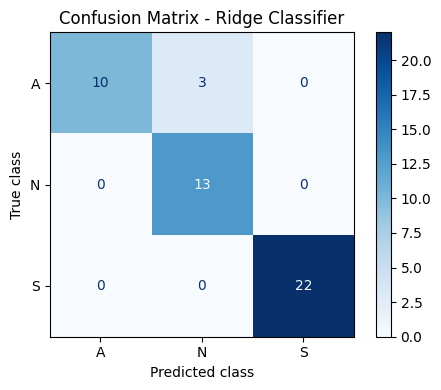


SVC RBF
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.8667    1.0000    0.9286        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9583        48
   macro avg     0.9556    0.9487    0.9484        48
weighted avg     0.9639    0.9583    0.9581        48



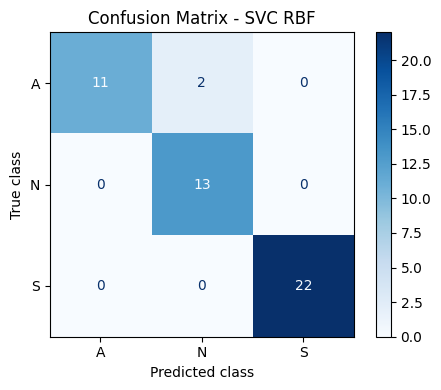


NuSVC
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.8667    1.0000    0.9286        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9583        48
   macro avg     0.9556    0.9487    0.9484        48
weighted avg     0.9639    0.9583    0.9581        48



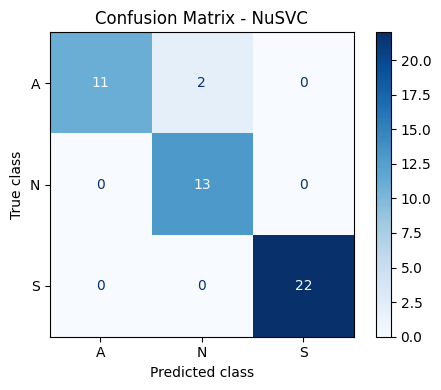


Random Forest
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



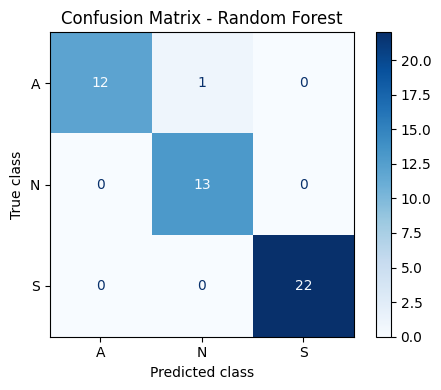


Neural Network
              precision    recall  f1-score   support

           A     0.9091    0.7692    0.8333        13
           N     0.6842    1.0000    0.8125        13
           S     1.0000    0.8182    0.9000        22

    accuracy                         0.8542        48
   macro avg     0.8644    0.8625    0.8486        48
weighted avg     0.8899    0.8542    0.8582        48



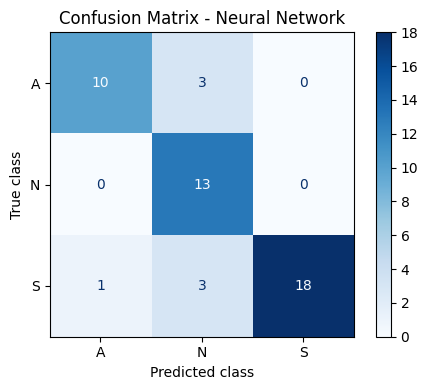


Linear SVC
              precision    recall  f1-score   support

           A     1.0000    0.7692    0.8696        13
           N     0.7647    1.0000    0.8667        13
           S     1.0000    0.9545    0.9767        22

    accuracy                         0.9167        48
   macro avg     0.9216    0.9079    0.9043        48
weighted avg     0.9363    0.9167    0.9179        48



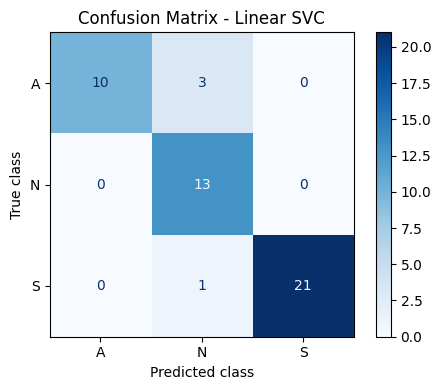


XGBoost
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



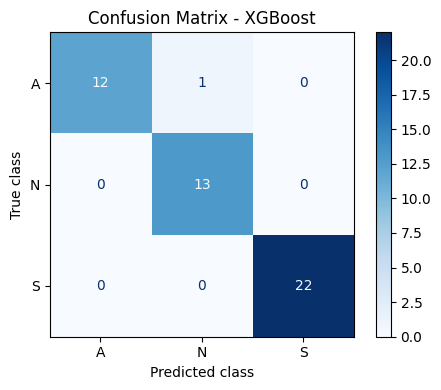


SGD Classifier
              precision    recall  f1-score   support

           A     1.0000    0.6154    0.7619        13
           N     0.6842    1.0000    0.8125        13
           S     1.0000    0.9545    0.9767        22

    accuracy                         0.8750        48
   macro avg     0.8947    0.8566    0.8504        48
weighted avg     0.9145    0.8750    0.8741        48



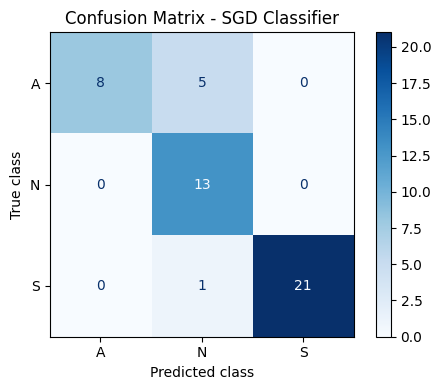


KNN
              precision    recall  f1-score   support

           A     1.0000    0.2308    0.3750        13
           N     0.3939    1.0000    0.5652        13
           S     1.0000    0.5455    0.7059        22

    accuracy                         0.5833        48
   macro avg     0.7980    0.5921    0.5487        48
weighted avg     0.8359    0.5833    0.5782        48



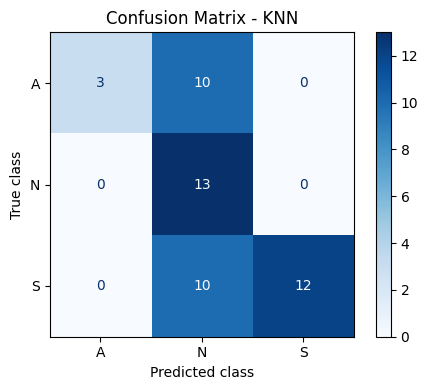

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression
              precision    recall  f1-score   support

           A     1.0000    0.8462    0.9167        13
           N     0.7647    1.0000    0.8667        13
           S     1.0000    0.9091    0.9524        22

    accuracy                         0.9167        48
   macro avg     0.9216    0.9184    0.9119        48
weighted avg     0.9363    0.9167    0.9195        48



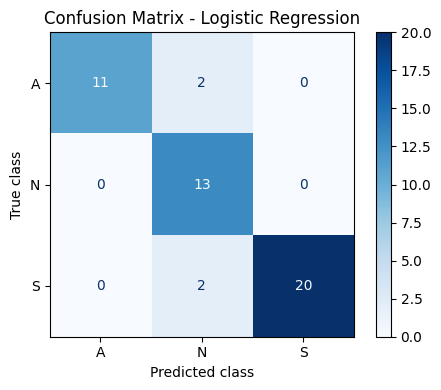


Bagging Classifier
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



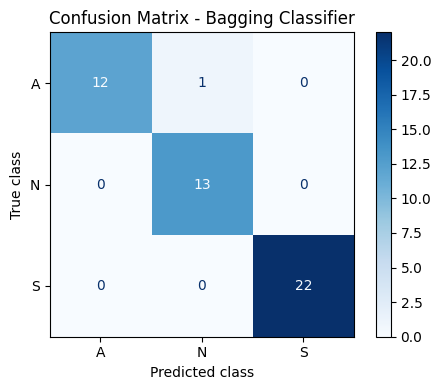


ExtraTrees Classifier
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    1.0000    0.9630        13
           S     1.0000    1.0000    1.0000        22

    accuracy                         0.9792        48
   macro avg     0.9762    0.9744    0.9743        48
weighted avg     0.9807    0.9792    0.9791        48



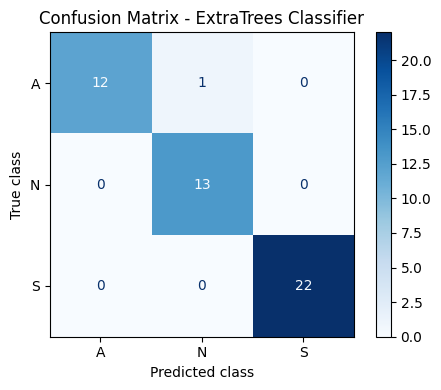

,Model,Accuracy,Balanced accuracy,Precision macro,Recall macro,F1 macro
3,Random Forest,0.979167,0.974359,0.976190,0.974359,0.974321
10,Bagging Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
11,ExtraTrees Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
6,XGBoost,0.979167,0.974359,0.976190,0.974359,0.974321
1,SVC RBF,0.958333,0.948718,0.955556,0.948718,0.948413
2,NuSVC,0.958333,0.948718,0.955556,0.948718,0.948413
0,Ridge Classifier,0.937500,0.923077,0.937500,0.923077,0.922039
5,Linear SVC,0.916667,0.907925,0.921569,0.907925,0.904325
9,Logistic Regression,0.916667,0.918415,0.921569,0.918415,0.911905
7,SGD Classifier,0.875000,0.856643,0.894737,0.856643,0.850383


In [25]:
os.makedirs("figures", exist_ok=True)

results = []

trained_models = {}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Balanced accuracy": bal_acc,
        "Precision macro": prec,
        "Recall macro": rec,
        "F1 macro": f1
    })

    trained_models[name] = pipe

    print("\n==============================")
    print(name)
    print("==============================")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap="Blues", ax=ax, colorbar=True)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    plt.tight_layout()
    plt.savefig(f"figures/confusion_matrix_{name.replace(' ', '_')}.png", dpi=600)
    plt.show()

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
results_df

Models comparations

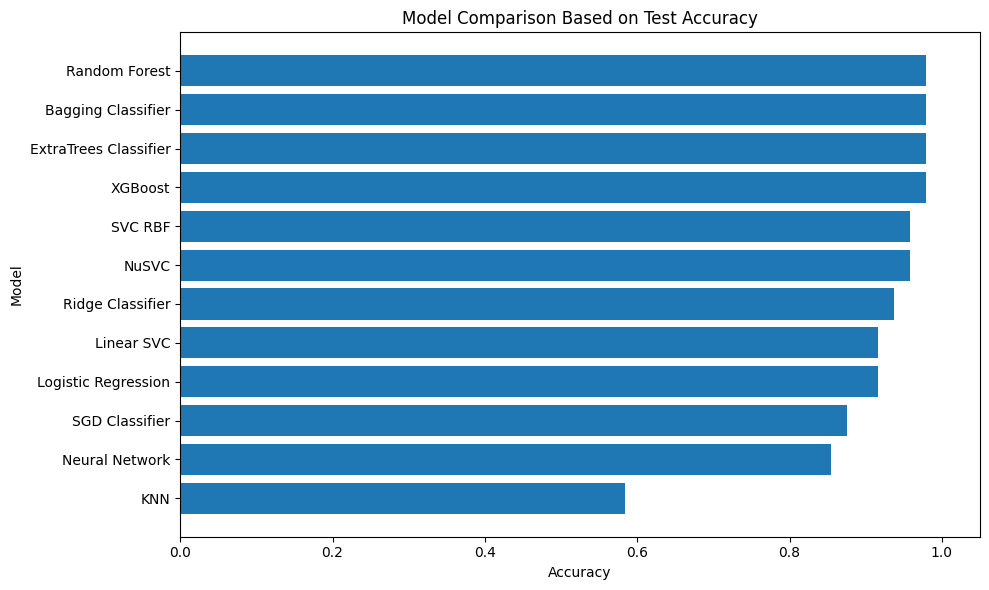

,Model,Accuracy,Balanced accuracy,Precision macro,Recall macro,F1 macro
3,Random Forest,0.979167,0.974359,0.976190,0.974359,0.974321
10,Bagging Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
11,ExtraTrees Classifier,0.979167,0.974359,0.976190,0.974359,0.974321
6,XGBoost,0.979167,0.974359,0.976190,0.974359,0.974321
1,SVC RBF,0.958333,0.948718,0.955556,0.948718,0.948413
2,NuSVC,0.958333,0.948718,0.955556,0.948718,0.948413
0,Ridge Classifier,0.937500,0.923077,0.937500,0.923077,0.922039
5,Linear SVC,0.916667,0.907925,0.921569,0.907925,0.904325
9,Logistic Regression,0.916667,0.918415,0.921569,0.918415,0.911905
7,SGD Classifier,0.875000,0.856643,0.894737,0.856643,0.850383


In [26]:
results_df.to_excel("model_comparison_metrics.xlsx", index=False)

plt.figure(figsize=(10, 6))
plt.barh(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison Based on Test Accuracy")
plt.xlim(0, 1.05)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("figures/model_comparison_accuracy.png", dpi=600)
plt.show()

results_df

ROC Multi-Class Curve

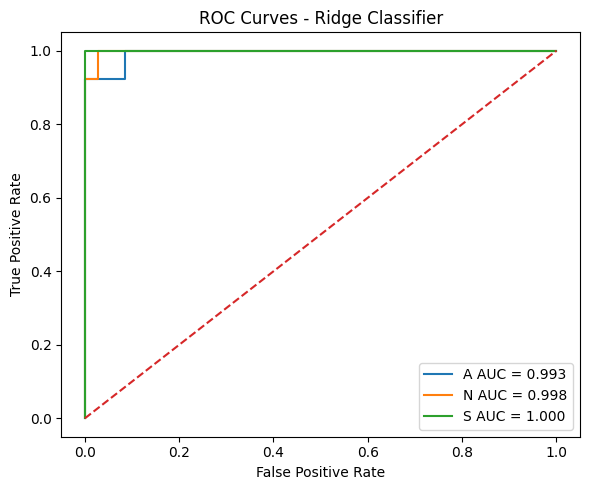

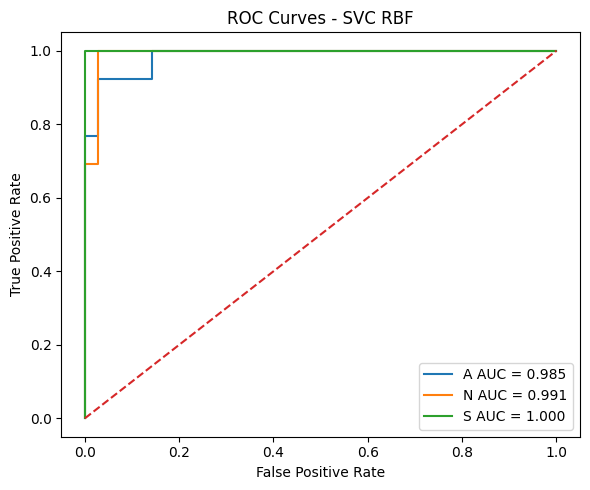

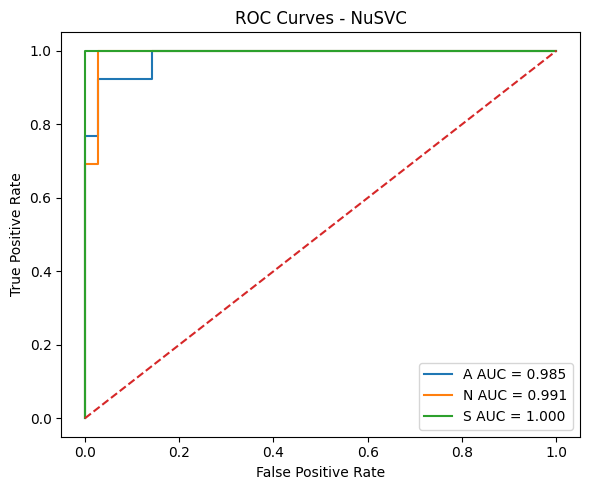

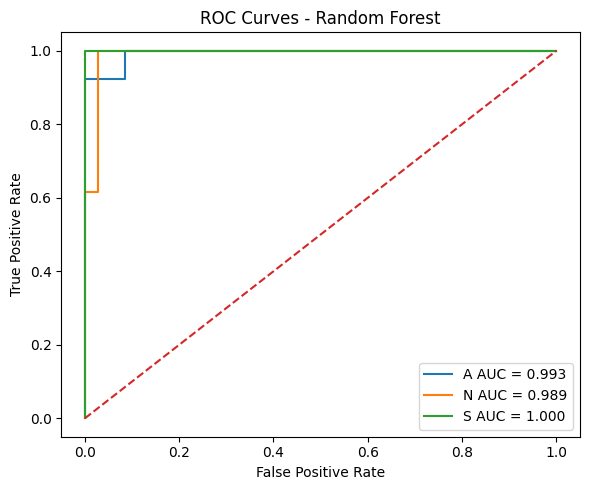

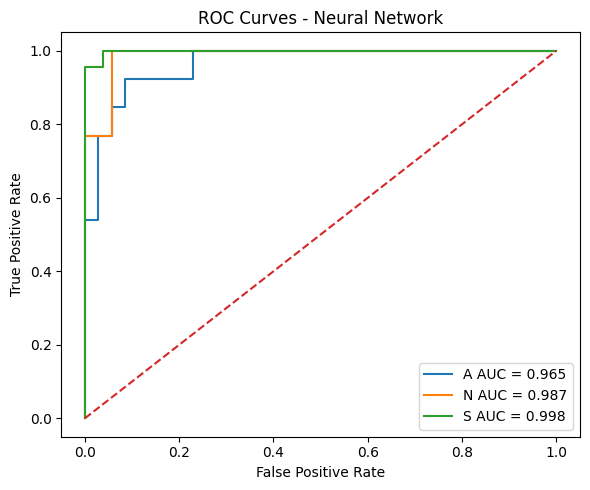

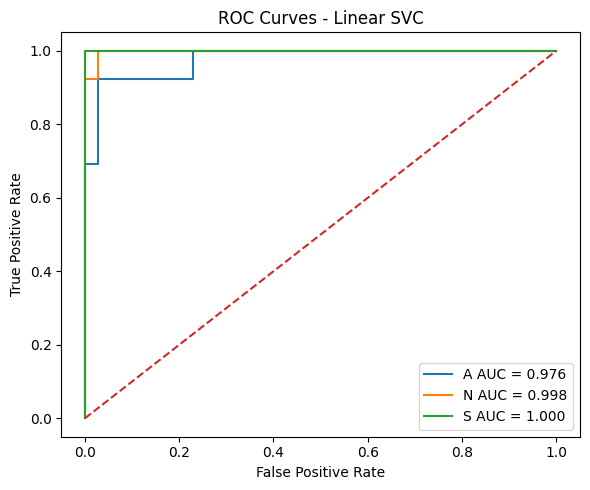

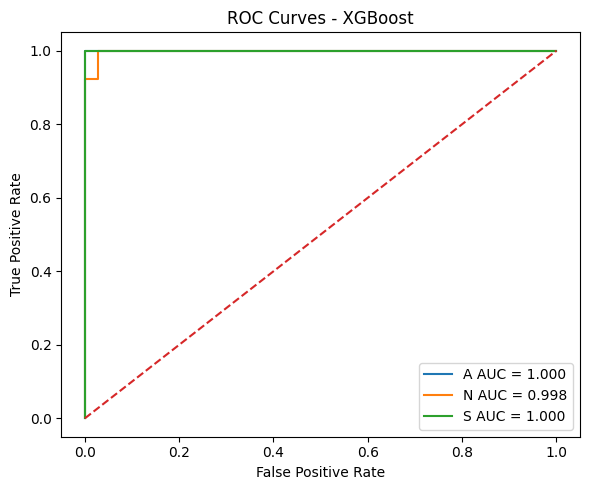

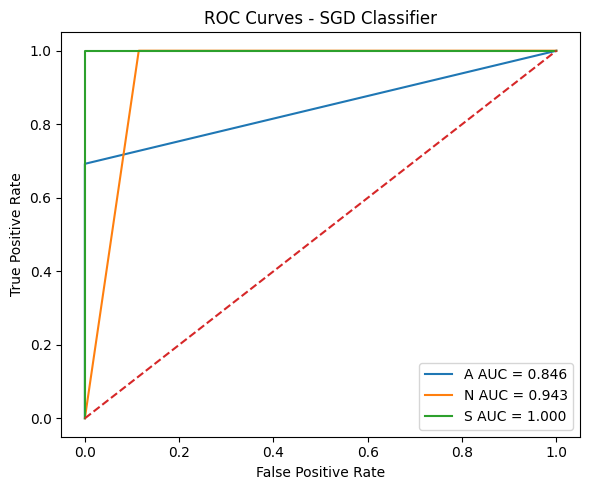

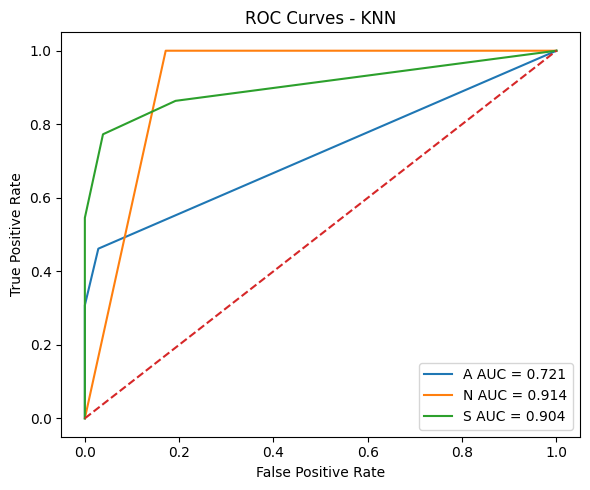

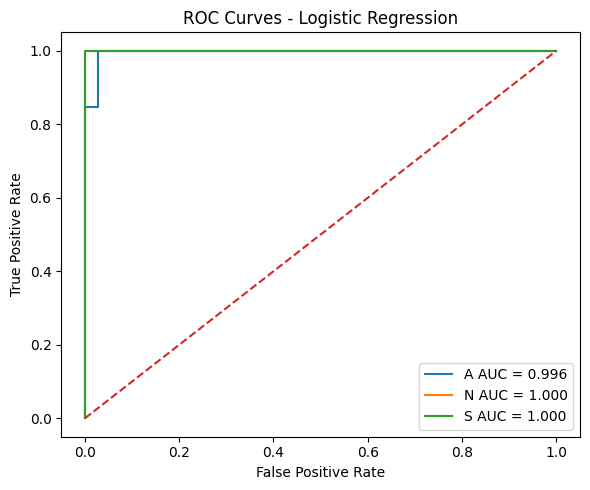

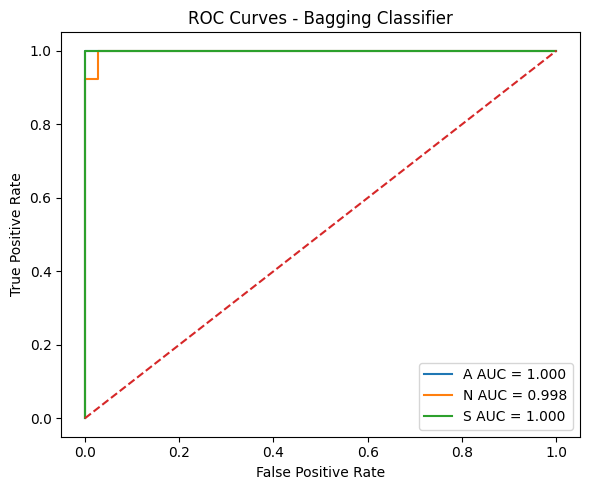

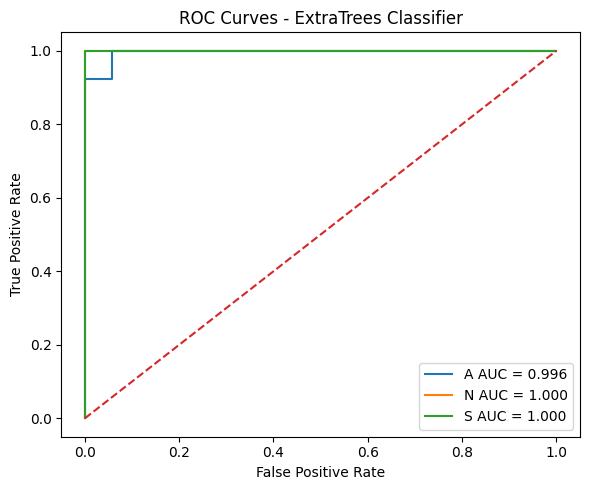

In [ ]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

for name, pipe in trained_models.items():

    model = pipe.named_steps["model"]

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)
    elif hasattr(pipe, "decision_function"):
        y_score = pipe.decision_function(X_test)
    else:
        continue

    plt.figure(figsize=(6, 5))

    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_name} AUC = {roc_auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {name}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"figures/roc_{name.replace(' ', '_')}.png", dpi=600)
    plt.show()

Validadation

In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=12)

cv_summary = []

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

for name, model in models.items():

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    cv_results = cross_validate(
        pipe,
        X,
        y_encoded,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    row = {"Model": name}

    for metric in scoring:
        values = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_sd"] = values.std()

    cv_summary.append(row)

cv_df = pd.DataFrame(cv_summary).sort_values("accuracy_mean", ascending=False)
cv_df.to_excel("cross_validation_metrics.xlsx", index=False)
cv_df